# 为什么选择可转债作为投资标的
## “进可攻退可守”的投资工具：在到达转股期后，可转债持有人既可选择持有债券到期，获得本息，亦可将债券转为股票，成为公司股东。在某种意义上，可转债可看做债券和期权的一个结合，同时包含债权性、股权性、期权性和可转化性。

## 可转债市场增长迅速
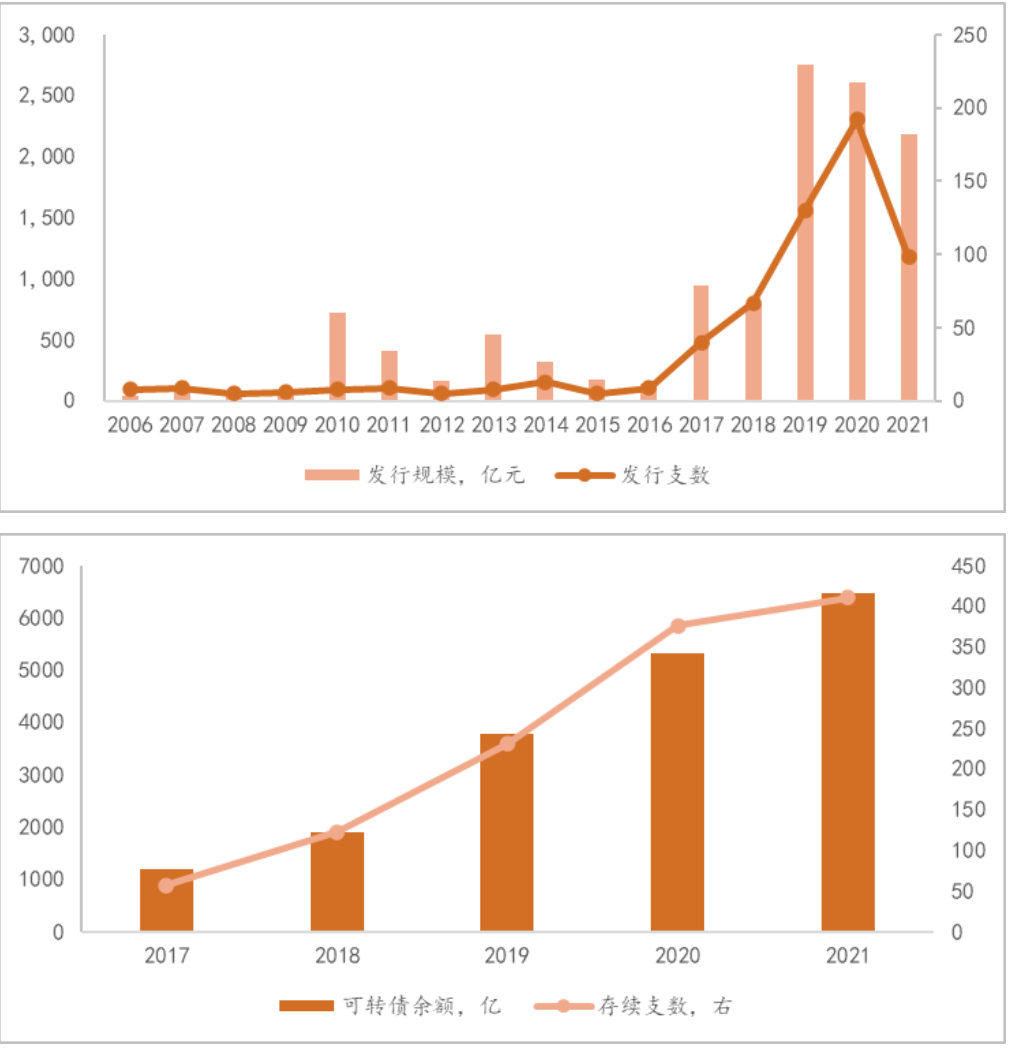

## 可转债手续费率低 
可转债交易收费标准各证券公司不同，一般来说可转债交易手续费是成交金额的0.04%，买卖双向收取，单笔最少1元，不收印花税和过户费。

股票交易收取佣金（买卖双向收取，不超过成交金额的3%，单笔最少5元），印花税（买入时不收，卖出时收成交金额的千分1），过户费（买卖双向收取，收取成交金额的千分之0.2）。

## 自相关性
可转债市场具有显著的自相关性，因此可由此构建趋势择时策略

In [1]:
import pandas as pd
zzzz= pd.read_excel("中证转债.xlsx",index_col='交易时间')
zzqz=pd.read_excel('中证全债.xls',index_col='交易时间')
hs300=pd.read_excel('沪深300.xls',index_col='交易时间')
df1=zzzz[['收盘价']]
df2=zzqz[['收盘价']]
df3=hs300[['收盘价']]
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')       #画图时把warning去掉
plt.rcParams['axes.unicode_minus'] = False    #正常显示负号

plot_acf(np.array(df1),title='zzzz_Autocorrelation')
plt.tight_layout()
plot_pacf(np.array(df1),title='zzzz_Autocorrelation')
plt.tight_layout()

plot_acf(np.array(df2),title='zzqz_Autocorrelation')
plt.tight_layout()
plot_pacf(np.array(df2),title='zzqz_Autocorrelation')
plt.tight_layout()

plot_acf(np.array(df3),title='hs300_Autocorrelation')
plt.tight_layout()
plot_pacf(np.array(df3),title='hs300_Autocorrelation')
plt.tight_layout()

d:\Anaconda3.1\lib\site-packages\pandas\compat\_optional.py:138: UserWarning: Pandas requires version '2.7.0' or newer of 'numexpr' (version '2.6.8' currently installed).
  warnings.warn(msg, UserWarning)


#  通道突破策略:唐奇安通道突破策略
## 假设可做空：当今天的收盘线下穿下通道（过去20天的最低价），则以收盘价做空下一天；上穿上通道（过去20天的最高价），则以收盘价做多下一天。（仅一天）

In [2]:
import pandas as pd
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
import matplotlib.pyplot as plt
import numpy as np
import warnings
zzzz= pd.read_excel("中证转债.xlsx",index_col='交易时间')
zzqz=pd.read_excel('中证全债.xls',index_col='交易时间')
hs300=pd.read_excel('沪深300.xls',index_col='交易时间')
df1=zzzz[['收盘价']]
df2=zzqz[['收盘价']]
df3=hs300[['收盘价']]

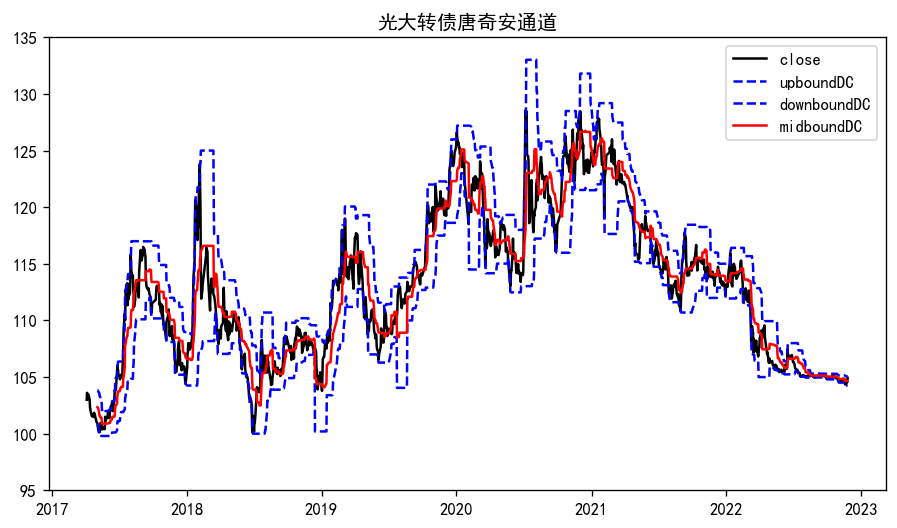

In [3]:
GD = pd.read_excel('光大转债.xls')
GD.index = GD['交易时间']
close=GD['收盘价']
high=GD['最高价']
low=GD['最低价']
#设定上中下通道线初始值
upboundDC = pd.Series(0.0,index=close.index)
downboundDC= pd.Series(0.0,index=close.index)
midboundDC=pd.Series(0.0,index=close.index)
#求唐奇安上中下通道
for i in range(20,len(close)):
    upboundDC[i]=max(high[(i-20):i])
    downboundDC[i]=min(low[(i-20):i])
    midboundDC[i]=0.5*(upboundDC[i]+downboundDC[i])
    
#从20天后再开始取通道
upboundDC=upboundDC[20:]
downboundDC=downboundDC[20:]
midboundDC=midboundDC[20:]
#绘制光大转债价格唐奇安通道上中下轨道线图
plt.figure(figsize=(9,5),dpi=120)
plt.rcParams['font.sans-serif']=['SimHei']  #运行配置参数中的字体（font）为黑体（SimHei）
plt.plot(close,label='close',color='k')
plt.plot(upboundDC,label='upboundDC',color='b',linestyle='dashed')
plt.plot(downboundDC,label='downboundDC',color='b',linestyle='dashed')
plt.plot(midboundDC,label='midboundDC',color='r',linestyle='-')
plt.title('光大转债唐奇安通道')
plt.ylim(95,135)            #设置Y轴的上下限
plt.legend()

In [4]:
#可以做空的情况下，也就是单纯的想观测这个策略的准确性
#向上突破函数upbreak 和向下突破函数downbreak
def upbreak(tsLine,tsRefLine):
    n=min(len(tsLine),len(tsRefLine))   #tsLine代入K线，tsRefline代入通道线
    tsLine=tsLine[-n:]                  #因为tsRefLine是前20天的数据计算得来，最开始会缺失20天的数据。不过代入close[upboundDC.index[0]:]同理
    tsRefLine=tsRefLine[-n:]
    signal=pd.Series(0,index=tsLine.index)
    for i in range(1,len(tsLine)):
        if all([tsLine[i]>tsRefLine[i],tsLine[i-1]<tsRefLine[i-1]]):
            signal[i]=1
    return signal

def downbreak(tsLine,tsRefLine):
    n=min(len(tsLine),len(tsRefLine))   
    tsLine=tsLine[-n:]   
    tsRefLine=tsRefLine[-n:]
    signal=pd.Series(0,index=tsLine.index)
    for i in range(1,len(tsLine)):
        if all([tsLine[i]<tsRefLine[i],tsLine[i-1]>tsRefLine[i-1]]):
            signal[i]=1
    return signal
#上下突破信号
UpBreak=upbreak(close[upboundDC.index[0]:],upboundDC)
DownBreak=downbreak(close[downboundDC.index[0]:],downboundDC)
#合并上下突破信号，上穿，signal为1，下穿，signal为-1
BreakSig=UpBreak-DownBreak
#计算预测胜率,信号为-1这里在做空
tradeSig=BreakSig.shift(1)
ret=close/close.shift(1)-1
tradeRet=(tradeSig*ret).dropna()
winRate=len(tradeRet[tradeRet>0])/len(tradeRet[tradeRet!=0])
print("预测的获胜率:",winRate)
df = pd.DataFrame({'tradeSig':tradeSig,
                   'tradeRet':tradeRet})
#多头胜率
long=df[df['tradeSig']==1]
x=sum(long['tradeRet']>0)/len(long['tradeRet'])
print("多头胜率:",x)
#空头胜率
short=df[df['tradeSig']==-1]
y=sum(short['tradeRet']>0)/len(short['tradeRet'])
print("空头胜率：",y)

预测的获胜率: 0.6027397260273972
多头胜率: 0.5172413793103449
空头胜率： 0.6444444444444445


## 实际情况（只做多）当当日收盘价高于上通道线，买入，持续持仓；当小于下通道线，空仓

In [5]:
pd.options.mode.chained_assignment = None
def strategy1(stock,n1,n2):
    #设置上下通道
    high=stock['最高价']
    low=stock['最低价']
    upbound=pd.Series(0,index=stock.index) 
    downbound=pd.Series(0,index=stock.index)
    for i in range(n1,len(stock['收盘价'])):             
        upbound[i] = max(high.iloc[(i-n1):i])    #lco不能有整型索引，iloc不能用标签索引
    for i in range(n2,len(stock['收盘价'])):
        downbound[i]=min(low.iloc[(i-n2):i])
    stock['upbound']=upbound
    stock['downbound']=downbound
    #设置买入信号，发出的信号是对下一天仓位的判断
    #信号初值设为空值，不然每一次调用函数后，数据被更改会被保留
    stock['signal']=np.nan
    #先取出买卖点的日期索引
    buy_date = stock[stock['收盘价']>stock["upbound"]].index
    #根据日期索引给signal赋值
    stock.loc[buy_date,'signal']=1
    sell_date = stock[stock['收盘价']<stock['downbound']].index
    stock.loc[sell_date,'signal']=0
    
    
    #一旦买入后，只有在低于下通道线才卖出空仓，所以当股价位于两条通道线中间时，是不会触发信号的
    stock['当天仓位']=stock['signal'].shift(1)
    stock['当天仓位'][0]=0
    stock['当天仓位'].fillna(method='ffill',inplace=True)
    stock['ret'] = stock['收盘价']/stock['收盘价'].shift(1)-1
    stock['ret'][0]=0  #要赋予初值，不然第一天会NAN
    stock['策略净值']=(stock['当天仓位']*stock['ret']+1).cumprod()
    stock['原始净值']=(stock['ret']+1).cumprod()
    stock['策略收益率']=stock['策略净值']/stock['策略净值'].shift(1)-1
    stock['原始收益率']=stock['ret']
    total_ret=stock[['策略净值','原始净值']].iloc[-1]-1
    #annual_ret =pow(total_ret,250/len(stock))-1
    annual_ret=(total_ret+1)**(250/len(stock))-1
    drawdown_rate=(stock[['策略净值','原始净值']].cummax()-stock[['策略净值','原始净值']])/stock[['策略净值','原始净值']].cummax()
    maxdrawdown_rate=drawdown_rate.max()
    exReturn=stock['策略收益率']-0.03/250
    sharpe_radio=exReturn.mean()/np.std(stock['策略收益率'])*np.sqrt(250)
    #开始画图
    #对数据乘以100，再保留两位小数，是为了下面显示百分比形式
    #开始画图
    #对数据乘以100，再保留两位小数，是为了下面显示百分比形式
    TR1=round(total_ret['策略净值']*100,2)
    TR2=round(total_ret['原始净值']*100,2)
    AR1=round(annual_ret['策略净值']*100,2)
    AR2=round(annual_ret['原始净值']*100,2)
    MD1=round(maxdrawdown_rate['策略净值']*100,2)
    MD2=round(maxdrawdown_rate['原始净值']*100,2)
    S=round(sharpe_radio,2)
    stock[['策略净值','原始净值']].plot(figsize=(9,7))
    bbox=dict(boxstyle='round',fc='w',ec='0.5',alpha=0.9)
    plt.text(stock.index[int(len(stock)/5)],stock['原始净值'].max()/1.5,f'''累积收益率：策略{TR1}% ,原始{TR2}%;
              \n年化收益率：策略{AR1}%，原始{AR2}%;
             \n最大回撤：策略{MD1}%,原始{MD2}%;
             \n夏普比率：{S}''',size=13,bbox=bbox)
    plt.title('唐奇安通道策略',size=15)
    plt.xlabel('')
    ax=plt.gca()
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')
    plt.show()

### 对光大转债进行择时

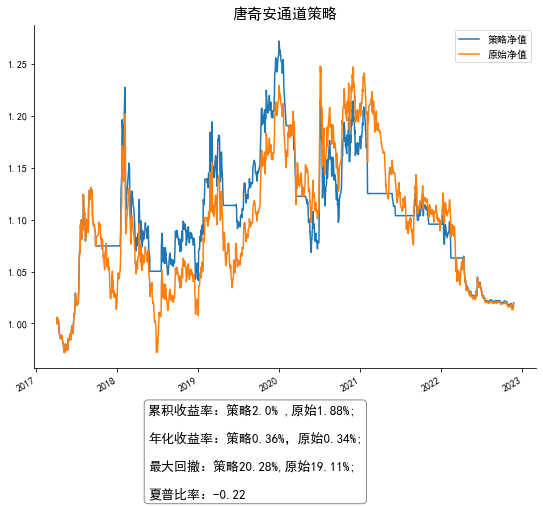

In [6]:
gdzz = pd.read_excel('光大转债.xls',index_col='交易时间')                                
strategy1(gdzz,20,20)

###  对中证转债指数进行择时

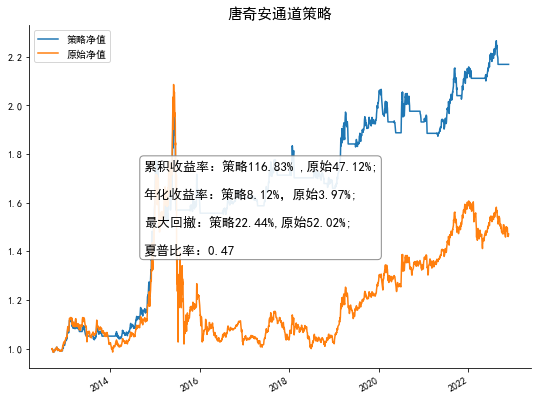

In [7]:
zzzz = pd.read_excel('中证转债.xlsx',index_col='交易时间')  
strategy1(zzzz,20,20)

### 对沪深300进行择时

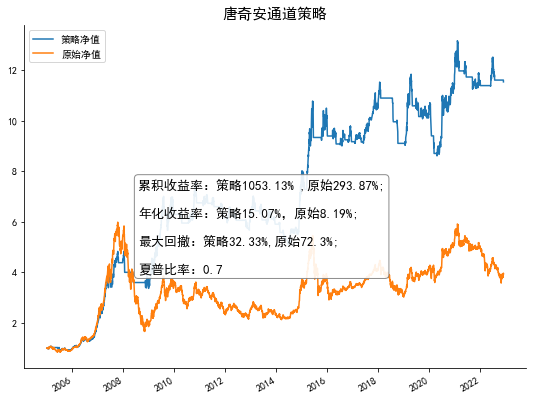

In [8]:
hs300 = pd.read_excel('沪深300.xls',index_col='交易时间')
strategy1(hs300,20,20)

### 对中证全债进行择时

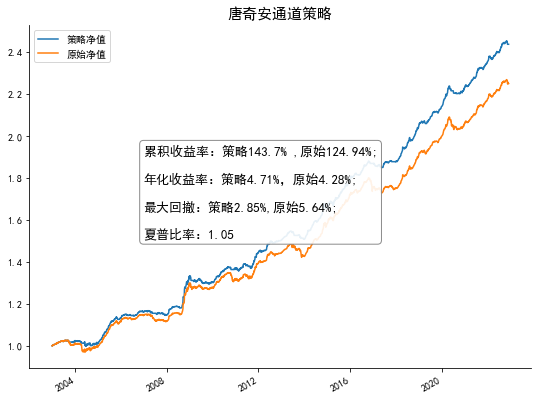

In [9]:
zzqz = pd.read_excel('中证全债.xls',index_col='交易时间')
strategy1(zzqz,20,20)

### 对中证转债2018年以后的数据进行择时

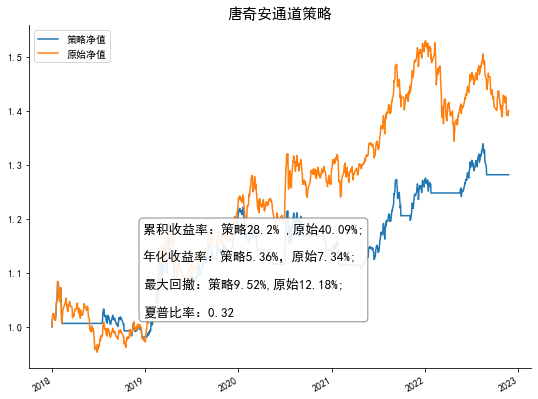

In [10]:
zzzz=pd.read_excel('中证转债.xlsx',index_col='交易时间')
zzzz2018=zzzz['2018':]
strategy1(zzzz2018,20,20)

# 对转债加入隐含波动率择时

In [11]:
pd.options.mode.chained_assignment = None
def strategy2(stock,n1,n2,x):
    #设置上下通道
    high=stock['最高价']
    low=stock['最低价']
    upbound=pd.Series(0,index=stock.index) 
    downbound=pd.Series(0,index=stock.index)
    for i in range(n1,len(stock['收盘价'])):             
        upbound[i] = max(high.iloc[(i-n1):i])     #lco不能有整型索引，iloc不能用标签索引  
    for i in range(n2,len(stock['收盘价'])):
        downbound[i]=min(low.iloc[(i-n2):i])
    stock['upbound']=upbound
    stock['downbound']=downbound
    #设置买入信号，发出的信号是对下一天仓位的判断
    #信号初值设为空值，不然每一次调用函数后，数据被更改会被保留
    stock['signal']=np.nan
    #先取出买卖点的日期索引
    buy_date = stock[stock['收盘价']>stock["upbound"]].index
    #根据日期索引给signal赋值
    stock.loc[buy_date,'signal']=1
    #当前一天隐含波动率高于阈值时，直接卖出
    sell_date = stock[(stock['收盘价']<stock['downbound'])|(stock['隐含波动率']>x)].index
    stock.loc[sell_date,'signal']=0
    
    #一旦买入后，只有在低于下通道线才卖出空仓，所以当股价位于两条通道线中间时，是不会触发信号的
    stock['当天仓位']=stock['signal'].shift(1)
    stock['当天仓位'][0]=0
    stock['当天仓位'].fillna(method='ffill',inplace=True)
    stock['ret'] = stock['收盘价']/stock['收盘价'].shift(1)-1
    stock['ret'][0]=0  #要赋予初值，不然第一天会NAN
    stock['策略净值']=(stock['当天仓位']*stock['ret']+1).cumprod()
    stock['原始净值']=(stock['ret']+1).cumprod()
    stock['策略收益率']=stock['策略净值']/stock['策略净值'].shift(1)-1
    stock['原始收益率']=stock['ret']
    total_ret=stock[['策略净值','原始净值']].iloc[-1]-1
    #annual_ret =pow(total_ret,250/len(stock))-1
    annual_ret=(total_ret+1)**(250/len(stock))-1
    drawdown_rate=(stock[['策略净值','原始净值']].cummax()-stock[['策略净值','原始净值']])/stock[['策略净值','原始净值']].cummax()
    maxdrawdown_rate=drawdown_rate.max()
    exReturn=stock['策略收益率']-0.03/250
    sharpe_radio=exReturn.mean()/np.std(stock['策略收益率'])*np.sqrt(250)
    #开始画图
    #对数据乘以100，再保留两位小数，是为了下面显示百分比形式
    #开始画图
    #对数据乘以100，再保留两位小数，是为了下面显示百分比形式
    TR1=round(total_ret['策略净值']*100,2)
    TR2=round(total_ret['原始净值']*100,2)
    AR1=round(annual_ret['策略净值']*100,2)
    AR2=round(annual_ret['原始净值']*100,2)
    MD1=round(maxdrawdown_rate['策略净值']*100,2)
    MD2=round(maxdrawdown_rate['原始净值']*100,2)
    S=round(sharpe_radio,2)
    stock[['策略净值','原始净值']].plot(figsize=(9,7))
    bbox=dict(boxstyle='round',fc='w',ec='0.5',alpha=0.9)
    plt.text(stock.index[int(len(stock)/5)],stock['原始净值'].max()/1.5,f'''累积收益率：策略{TR1}% ,原始{TR2}%;
              \n年化收益率：策略{AR1}%，原始{AR2}%;
             \n最大回撤：策略{MD1}%,原始{MD2}%;
             \n夏普比率：{S}''',size=13,bbox=bbox)
    plt.title('唐奇安通道策略',size=15)
    plt.xlabel('')
    ax=plt.gca()
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')
    plt.show()

In [12]:
volatility1 = zzzz2018[['隐含波动率']]
volatility2 = zzzz[['隐含波动率']]
display(volatility1.describe())
display(volatility2.describe())

,隐含波动率
count,1190.000000
mean,27.080721
std,6.668628
min,17.632244
25%,22.337399
50%,24.288738
75%,32.242986
max,44.147226


,隐含波动率
count,1386.000000
mean,26.405706
std,6.701621
min,10.744492
25%,21.908762
50%,24.090573
75%,29.542459
max,44.147226


## 对中证转债2018年以后数据加入隐含波动率择时

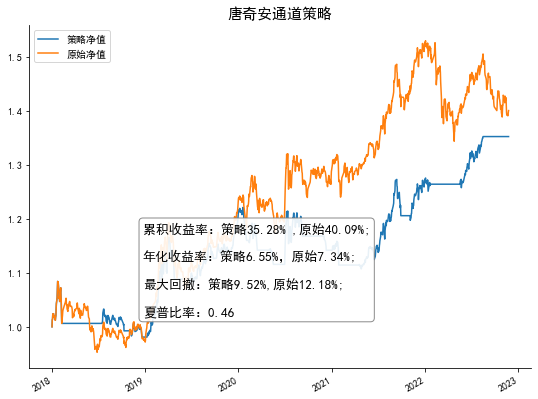

In [13]:
zzzz=pd.read_excel('中证转债.xlsx',index_col='交易时间')
zzzz2018=zzzz['2018':]
strategy2(zzzz2018,20,20,42)    #效果不好,42的选择有点随意

# 在隐含波动率基础上对转债继续加入转换价值择时

In [14]:
pd.options.mode.chained_assignment = None
def strategy3(stock,n1,n2,x,y1,y2):
    #设置上下通道
    high=stock['最高价']
    low=stock['最低价']
    upbound=pd.Series(0,index=stock.index) 
    downbound=pd.Series(0,index=stock.index)
    for i in range(n1,len(stock['收盘价'])):             
        upbound[i] = max(high.iloc[(i-n1):i])     #lco不能有整型索引，iloc不能用标签索引   
    for i in range(n2,len(stock['收盘价'])):
        downbound[i]=min(low.iloc[(i-n2):i])
    stock['upbound']=upbound
    stock['downbound']=downbound
    #设置买入信号，发出的信号是对下一天仓位的判断
    #信号初值设为空值，不然每一次调用函数后，数据被更改会被保留
    stock['signal']=np.nan
    #先取出买卖点的日期索引
    #当转换价值小于y1时，也买入
    buy_date = stock[(stock['收盘价']>stock["upbound"])|(stock['转换价值']<y1)].index
    #根据日期索引给signal赋值
    stock.loc[buy_date,'signal']=1
    #当前一天转换价值大于y2时，也卖出
    sell_date = stock[(stock['收盘价']<stock['downbound'])|(stock['隐含波动率']>x)|(stock['转换价值']>y2)].index
    stock.loc[sell_date,'signal']=0
    
    #一旦买入后，只有在低于下通道线才卖出空仓，所以当股价位于两条通道线中间时，是不会触发信号的
    stock['当天仓位']=stock['signal'].shift(1)
    stock['当天仓位'][0]=0
    stock['当天仓位'].fillna(method='ffill',inplace=True)
    stock['ret'] = stock['收盘价']/stock['收盘价'].shift(1)-1
    stock['ret'][0]=0  #要赋予初值，不然第一天会NAN
    stock['策略净值']=(stock['当天仓位']*stock['ret']+1).cumprod()
    stock['原始净值']=(stock['ret']+1).cumprod()
    stock['策略收益率']=stock['策略净值']/stock['策略净值'].shift(1)-1
    stock['原始收益率']=stock['ret']
    total_ret=stock[['策略净值','原始净值']].iloc[-1]-1
    #annual_ret =pow(total_ret,250/len(stock))-1
    annual_ret=(total_ret+1)**(250/len(stock))-1
    drawdown_rate=(stock[['策略净值','原始净值']].cummax()-stock[['策略净值','原始净值']])/stock[['策略净值','原始净值']].cummax()
    maxdrawdown_rate=drawdown_rate.max()
    exReturn=stock['策略收益率']-0.03/250
    sharpe_radio=exReturn.mean()/np.std(stock['策略收益率'])*np.sqrt(250)
    #开始画图
    #对数据乘以100，再保留两位小数，是为了下面显示百分比形式
    #开始画图
    #对数据乘以100，再保留两位小数，是为了下面显示百分比形式
    TR1=round(total_ret['策略净值']*100,2)
    TR2=round(total_ret['原始净值']*100,2)
    AR1=round(annual_ret['策略净值']*100,2)
    AR2=round(annual_ret['原始净值']*100,2)
    MD1=round(maxdrawdown_rate['策略净值']*100,2)
    MD2=round(maxdrawdown_rate['原始净值']*100,2)
    S=round(sharpe_radio,2)
    stock[['策略净值','原始净值']].plot(figsize=(9,7))
    bbox=dict(boxstyle='round',fc='w',ec='0.5',alpha=0.9)
    plt.text(stock.index[int(len(stock)/5)],stock['原始净值'].max()/1.5,f'''累积收益率：策略{TR1}% ,原始{TR2}%;
              \n年化收益率：策略{AR1}%，原始{AR2}%;
             \n最大回撤：策略{MD1}%,原始{MD2}%;
             \n夏普比率：{S}''',size=13,bbox=bbox)
    plt.title('唐奇安通道策略',size=15)
    plt.xlabel('')
    ax=plt.gca()
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')
    plt.show()

## 对中证转债2018年以后数据继续加入转换价值择时

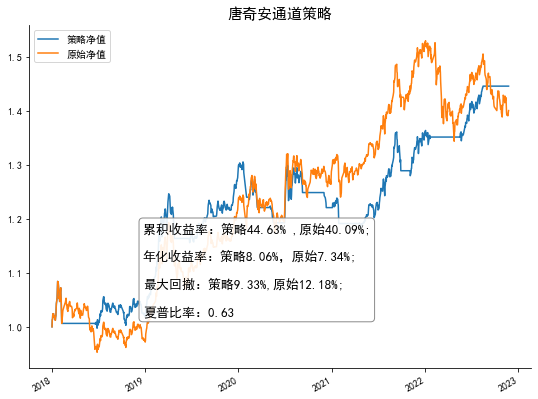

In [15]:
zzzz=pd.read_excel('中证转债.xlsx',index_col='交易时间')
zzzz2018=zzzz['2018':]
strategy3(zzzz2018,20,20,42,80,130) 